#  Previsão de Preço de Veículos Usados no Brasil

> ⚠️ **Este conteúdo é destinado apenas para fins educacionais. Os dados exibidos são ilustrativos e podem não corresponder a situações reais.**

---

## Metodologia: CRISP-DM

| Fase | Descrição |
|---|---|
| 1️⃣ Entendimento do Negócio | Prever o valor de venda de veículos usados no Brasil |
| 2️⃣ Entendimento dos Dados | Análise Exploratória (EDA) |
| 3️⃣ Preparação dos Dados | Limpeza, imputação, feature engineering, encoding |
| 4️⃣ Modelagem | Comparação de 7 algoritmos de regressão |
| 5️⃣ Avaliação | Métricas + rastreamento com MLflow |
| 6️⃣ Implantação | Deploy no Hugging Face Spaces via Gradio |

**Dataset:** 10.000 registros de veículos usados  
**Variável alvo:** `Valor_Venda` (R$)

### Instalar libs

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

#import mlflow
#import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Diretórios de saída
os.makedirs('eda_outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

print(' Imports concluídos com sucesso!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   sklearn importado')
#print(f'   mlflow  {mlflow.__version__}')

 Imports concluídos com sucesso!
   pandas  2.2.2
   numpy   2.0.2
   sklearn importado


In [ ]:
df = pd.read_csv('/content/dataset_final.csv')

In [ ]:
df.head()

,Marca,Modelo,Ano,Quilometragem,Cor,Cambio,Combustivel,Portas,Valor_Venda,idade_carro
0,Nissan,Frontier,2000,117290,Cinza,Manual,Gasolina,4,43413.0,26
1,Ford,Ranger,2000,141406,Preto,Manual,Flex,4,33267.8,26
2,Toyota,Hilux,2000,138468,Branco,Manual,Flex,2,51867.4,26
3,Renault,Sandero,2000,105311,Azul,Manual,Gasolina,2,22289.8,26
4,Renault,Duster,2000,31654,Prata,Automático,Diesel,2,35878.2,26


### Aplicar onehotencoder nas colunas categoricas

In [ ]:
df.columns.tolist()

['Marca',
 'Modelo',
 'Ano',
 'Quilometragem',
 'Cor',
 'Cambio',
 'Combustivel',
 'Portas',
 'Valor_Venda',
 'idade_carro']

In [ ]:
colunas = ['Marca', 'Modelo', 'Cor', 'Cambio', 'Combustivel']

In [ ]:
lista_marcas = df['Marca'].unique().tolist()
lista_modelo = df['Modelo'].unique().tolist()
lista_cor = df['Cor'].unique().tolist()
lista_cambio = df['Cambio'].unique().tolist()
lista_combustivel = df['Combustivel'].unique().tolist()

In [ ]:
print('Marcas:', lista_marcas,
      '\nModelos:',lista_modelo,
      '\nCor:', lista_cor,
      '\nCamvbio:', lista_cambio,
      '\nCombustivel:',lista_combustivel)

Marcas: ['Nissan', 'Ford', 'Toyota', 'Renault', 'Fiat', 'Jeep', 'Honda', 'Volkswagen', 'Hyundai', 'Chevrolet'] 
Modelos: ['Frontier', 'Ranger', 'Hilux', 'Sandero', 'Duster', 'Kicks', 'Ka', 'Corolla', 'Mobi', 'Renegade', 'Compass', 'HR-V', 'T-Cross', 'Toro', 'HB20S', 'Yaris', 'EcoSport', 'Onix', 'Polo', 'Argo', 'Kwid', 'Virtus', 'Civic', 'Cronos', 'Gol', 'Versa', 'Creta', 'HB20', 'S10', 'Tracker', 'Onix Plus', 'Fit'] 
Cor: ['Cinza', 'Preto', 'Branco', 'Azul', 'Prata', 'Vermelho'] 
Camvbio: ['Manual', 'Automático'] 
Combustivel: ['Gasolina', 'Flex', 'Diesel']


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_features = encoder.fit_transform(df[colunas])

# Create a DataFrame with the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(colunas))

# Concatenate the original DataFrame with the new encoded features, dropping the original categorical columns
df_encoded = pd.concat([df.drop(columns=colunas), encoded_df], axis=1)

# Display the first few rows of the new DataFrame
display(df_encoded.head())

,Ano,Quilometragem,Portas,Valor_Venda,idade_carro,Marca_Chevrolet,Marca_Fiat,Marca_Ford,Marca_Honda,Marca_Hyundai,...,Cor_Branco,Cor_Cinza,Cor_Prata,Cor_Preto,Cor_Vermelho,Cambio_Automático,Cambio_Manual,Combustivel_Diesel,Combustivel_Flex,Combustivel_Gasolina
0,2000,117290,4,43413.0,26,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2000,141406,4,33267.8,26,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,2000,138468,2,51867.4,26,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,2000,105311,2,22289.8,26,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,2000,31654,2,35878.2,26,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
df_encoded.columns

Index(['Ano', 'Quilometragem', 'Portas', 'Valor_Venda', 'idade_carro',
       'Marca_Chevrolet', 'Marca_Fiat', 'Marca_Ford', 'Marca_Honda',
       'Marca_Hyundai', 'Marca_Jeep', 'Marca_Nissan', 'Marca_Renault',
       'Marca_Toyota', 'Marca_Volkswagen', 'Modelo_Argo', 'Modelo_Civic',
       'Modelo_Compass', 'Modelo_Corolla', 'Modelo_Creta', 'Modelo_Cronos',
       'Modelo_Duster', 'Modelo_EcoSport', 'Modelo_Fit', 'Modelo_Frontier',
       'Modelo_Gol', 'Modelo_HB20', 'Modelo_HB20S', 'Modelo_HR-V',
       'Modelo_Hilux', 'Modelo_Ka', 'Modelo_Kicks', 'Modelo_Kwid',
       'Modelo_Mobi', 'Modelo_Onix', 'Modelo_Onix Plus', 'Modelo_Polo',
       'Modelo_Ranger', 'Modelo_Renegade', 'Modelo_S10', 'Modelo_Sandero',
       'Modelo_T-Cross', 'Modelo_Toro', 'Modelo_Tracker', 'Modelo_Versa',
       'Modelo_Virtus', 'Modelo_Yaris', 'Cor_Azul', 'Cor_Branco', 'Cor_Cinza',
       'Cor_Prata', 'Cor_Preto', 'Cor_Vermelho', 'Cambio_Automático',
       'Cambio_Manual', 'Combustivel_Diesel', 'Combustivel_

### Dividir dados em treino e teste

In [ ]:
X = df_encoded.drop(columns=['Valor_Venda'])
y = df_encoded['Valor_Venda']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% para treino
#
print("X:", X.shape)
print("Treino (80%):",X_train.shape)
print("Teste (20%):",X_test.shape)

X: (9686, 57)
Treino (80%): (7748, 57)
Teste (20%): (1938, 57)


### Função para treinar e avaliar modelos

In [ ]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return mae, rmse, r2, mape

print('Função de avaliação definida: MAE, RMSE, R², MAPE')

Função de avaliação definida: MAE, RMSE, R², MAPE


In [ ]:
def train_and_evaluate_model(model_obj, model_name, X_train, y_train, X_test, y_test, feature_cols, lista_modelo, lista_r2, lista_mae, lista_rmse, lista_mape, lista_feature, lista_total_features):
    """
    Treina e avalia um modelo de regressão.

    Args:
        model_obj: O objeto do modelo a ser treinado (e.g., RandomForestRegressor, LGBMRegressor).
        model_name (str): O nome do modelo (para identificação nos resultados).
        X_train (pd.DataFrame): Dados de treino (features).
        y_train (pd.Series): Target de treino.
        X_test (pd.DataFrame): Dados de teste (features).
        y_test (pd.Series): Target de teste.
        feature_cols (list): Nomes das colunas de features.
        lista_modelo (list): Lista para armazenar os nomes dos modelos avaliados.
        lista_r2 (list): Lista para armazenar as métricas R² dos modelos.
        lista_mae (list): Lista para armazenar as métricas MAE dos modelos.
        lista_feature (list): Lista para armazenar a importância das features de cada modelo.
        lista_total_features (list): Lista para armazenar o total de features usadas em cada modelo.
    """
    print(f"\n--- Treinando e avaliando: {model_name} ---")

    # Treinar modelo
    model_obj.fit(X_train, y_train)

    # Fazer previsões
    y_pred = model_obj.predict(X_test)

    # Calcular métricas
    mae, rmse, r2, mape = evaluate(y_test, y_pred)

    # Imprimir resultados
    print(f"R²: {r2:.4f}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}")

    # Armazenar resultados
    lista_modelo.append(model_name)
    lista_r2.append(r2)
    lista_mae.append(mae)
    lista_rmse.append(rmse)
    lista_mape.append(mape)

    # Armazenar total de features usadas
    lista_total_features.append(len(feature_cols))

    # Importância das features
    if hasattr(model_obj, 'feature_importances_'):
        importancias = pd.DataFrame({
            'feature': feature_cols,
            'importancia': model_obj.feature_importances_
        }).sort_values('importancia', ascending=False)
        lista_feature.append(importancias)
        print("\nTop 10 features mais importantes:")
        display(importancias.head(10).reset_index(drop=True))
    else:
        print("Modelo não possui atributo feature_importances_.")
        lista_feature.append(None)



### Configurar os modelos a serem treinados e avaliados

In [ ]:
MODELS = {
    'Ridge': Ridge(alpha=6.0),
    'Lasso': Lasso(alpha=6.0),
    'RandomForest': RandomForestRegressor( n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=100, max_depth=12,
        n_jobs=-1, random_state=42
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=200,
        subsample=0.8, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100,  random_state=42, verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=300, random_state=42, verbose=-1
    ),
}
print(f'Total de modelos a comparar: {len(MODELS)}')
for nome in MODELS:
    print(f'  · {nome}')

Total de modelos a comparar: 7
  · Ridge
  · Lasso
  · RandomForest
  · ExtraTrees
  · GradientBoosting
  · XGBoost
  · LightGBM


### Iniciar treinamento e avaliação

In [ ]:
# Inicializar listas para armazenamento de resultados
lista_modelo = []
lista_r2 = []
lista_mae = []
lista_rmse = []
lista_mape = []
lista_total_features = []
lista_feature = []

feature_cols = X.columns


# Chamar a função para cada modelo
for name, model in MODELS.items():
    train_and_evaluate_model(model, name, X_train, y_train, X_test, y_test, feature_cols, lista_modelo, lista_r2, lista_mae, lista_rmse, lista_mape, lista_feature, lista_total_features)


# Exibir um resumo das métricas (opcional, após todos os modelos serem avaliados)
print("\n--- Resumo das Avaliações ---")
resultados_df = pd.DataFrame({
    'Modelo': lista_modelo,
    'R²': lista_r2,
    'MAE': lista_mae,
    'RMSE': lista_rmse,
    'MAPE': lista_mape,
    'Total de Features': lista_total_features
})
display(resultados_df)


--- Treinando e avaliando: Ridge ---
R²: 0.9773
MAE : 2601.08
RMSE : 3117.14
MAPE : 5.06
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: Lasso ---
R²: 0.9773
MAE : 2599.90
RMSE : 3112.93
MAPE : 5.06
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: RandomForest ---
R²: 0.9713
MAE : 2858.36
RMSE : 3500.10
MAPE : 5.61

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,0.315527
1,Marca_Jeep,0.186922
2,idade_carro,0.129239
3,Ano,0.109210
4,Marca_Toyota,0.102242
5,Marca_Honda,0.088400
6,Marca_Nissan,0.031703
7,Marca_Ford,0.016228
8,Marca_Hyundai,0.004481
9,Marca_Renault,0.001289



--- Treinando e avaliando: ExtraTrees ---
R²: 0.9703
MAE : 2923.83
RMSE : 3562.93
MAPE : 5.84

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,0.303733
1,Marca_Jeep,0.187979
2,idade_carro,0.128880
3,Ano,0.113267
4,Marca_Toyota,0.106173
5,Marca_Honda,0.094111
6,Marca_Nissan,0.034895
7,Marca_Ford,0.018297
8,Marca_Hyundai,0.004851
9,Portas,0.000591



--- Treinando e avaliando: GradientBoosting ---
R²: 0.9745
MAE : 2715.29
RMSE : 3303.41
MAPE : 5.30

Top 10 features mais importantes:


...

,feature,importancia
0,Marca_Jeep,0.372644
1,Marca_Toyota,0.196375
2,Marca_Honda,0.181326
3,Marca_Nissan,0.050100
4,Marca_Fiat,0.039179
5,Marca_Renault,0.036043
6,Marca_Volkswagen,0.029640
7,Marca_Chevrolet,0.025429
8,Ano,0.024446
9,Quilometragem,0.022156



--- Treinando e avaliando: LightGBM ---
R²: 0.9741
MAE : 2726.80
RMSE : 3324.63
MAPE : 5.33

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,3206
1,Ano,1912
2,Cambio_Automático,386
3,Portas,384
4,Combustivel_Diesel,199
5,Combustivel_Gasolina,189
6,Combustivel_Flex,179
7,Marca_Jeep,164
8,Marca_Toyota,157
9,Marca_Honda,149



--- Resumo das Avaliações ---


,Modelo,R²,MAE,RMSE,MAPE,Total de Features
0,Ridge,0.977251,2601.079484,3117.142490,5.062635,57
1,Lasso,0.977313,2599.902041,3112.933969,5.060632,57
2,RandomForest,0.971319,2858.364309,3500.095768,5.612740,57
3,ExtraTrees,0.970279,2923.825488,3562.934428,5.844046,57
4,GradientBoosting,0.974452,2715.285556,3303.405708,5.298183,57
5,XGBoost,0.970990,2865.946335,3520.104147,5.643245,57
6,LightGBM,0.974122,2726.799631,3324.626951,5.332768,57


### Selecionar as 5 e 10 melhores features e retreinar o melhor modelo.
### A escolha foi baseada na lista de features mais importantes dos melhores modelos.
### Avaliar novamente.

In [ ]:
features_5 = ['Quilometragem', 'Ano', 'Marca_Toyota', 'Marca_Jeep', 'Marca_Honda']
#
X = df_encoded[features_5]
y = df_encoded['Valor_Venda']
#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% para treino
#
print("X:", X.shape)
print("Treino (80%):",X_train.shape)
print("Teste (20%):",X_test.shape)

X: (9686, 5)
Treino (80%): (7748, 5)
Teste (20%): (1938, 5)


### Treinar com as 5 melhores features

In [ ]:
feature_cols = X.columns

# Chamar a função para cada modelo
for name, model in MODELS.items():
    train_and_evaluate_model(model, name, X_train, y_train, X_test, y_test, feature_cols, lista_modelo, lista_r2, lista_mae, lista_rmse, lista_mape, lista_feature, lista_total_features)

# Exibir um resumo das métricas (opcional, após todos os modelos serem avaliados)
print("\n--- Resumo das Avaliações ---")
resultados_df = pd.DataFrame({
    'Modelo': lista_modelo,
    'R²': lista_r2,
    'MAE': lista_mae,
    'RMSE': lista_rmse,
    'MAPE': lista_mape,
    'Total de Features': lista_total_features
})
display(resultados_df)


--- Treinando e avaliando: Ridge ---
R²: 0.9132
MAE : 4857.15
RMSE : 6087.63
MAPE : 10.12
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: Lasso ---
R²: 0.9133
MAE : 4850.58
RMSE : 6086.13
MAPE : 10.10
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: RandomForest ---
R²: 0.8863
MAE : 5404.60
RMSE : 6968.90
MAPE : 11.12

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,0.374925
1,Ano,0.247508
2,Marca_Jeep,0.186924
3,Marca_Toyota,0.102243
4,Marca_Honda,0.088401



--- Treinando e avaliando: ExtraTrees ---
R²: 0.9094
MAE : 4950.98
RMSE : 6220.95
MAPE : 10.28

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,0.331785
1,Ano,0.259089
2,Marca_Jeep,0.198389
3,Marca_Toyota,0.111770
4,Marca_Honda,0.098967



--- Treinando e avaliando: GradientBoosting ---
R²: 0.9105
MAE : 4920.16
RMSE : 6182.67
MAPE : 10.23

Top 10 features mais importantes:


...

,feature,importancia
0,Marca_Jeep,0.497759
1,Marca_Toyota,0.220326
2,Marca_Honda,0.168887
3,Quilometragem,0.059266
4,Ano,0.053762



--- Treinando e avaliando: LightGBM ---
R²: 0.9074
MAE : 4985.26
RMSE : 6290.45
MAPE : 10.31

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,5435
1,Ano,2889
2,Marca_Toyota,234
3,Marca_Honda,229
4,Marca_Jeep,213



--- Resumo das Avaliações ---


,Modelo,R²,MAE,RMSE,MAPE,Total de Features
0,Ridge,0.977251,2601.079484,3117.142490,5.062635,57
1,Lasso,0.977313,2599.902041,3112.933969,5.060632,57
2,RandomForest,0.971319,2858.364309,3500.095768,5.612740,57
3,ExtraTrees,0.970279,2923.825488,3562.934428,5.844046,57
4,GradientBoosting,0.974452,2715.285556,3303.405708,5.298183,57
5,XGBoost,0.970990,2865.946335,3520.104147,5.643245,57
6,LightGBM,0.974122,2726.799631,3324.626951,5.332768,57
7,Ridge,0.913236,4857.147574,6087.633411,10.121662,5
8,Lasso,0.913279,4850.583913,6086.127479,10.097947,5
9,RandomForest,0.886297,5404.600649,6968.902702,11.121153,5


### Treinar com as 10 melhores features

In [ ]:
features_10 = ['Quilometragem', 'Ano', 'Marca_Toyota', 'Marca_Jeep', 'Marca_Honda', 'Marca_Fiat', 'Marca_Renault', 'Marca_Volkswagen', 'Marca_Nissan', 'Marca_Ford']
#
X = df_encoded[features_10]
y = df_encoded['Valor_Venda']
#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% para treino
#
print("X:", X.shape)
print("Treino (80%):",X_train.shape)
print("Teste (20%):",X_test.shape)



X: (9686, 10)
Treino (80%): (7748, 10)
Teste (20%): (1938, 10)


In [ ]:
feature_cols = X.columns

# Chamar a função para cada modelo
for name, model in MODELS.items():
    train_and_evaluate_model(model, name, X_train, y_train, X_test, y_test, feature_cols, lista_modelo, lista_r2, lista_mae, lista_rmse, lista_mape, lista_feature, lista_total_features)

# Exibir um resumo das métricas (opcional, após todos os modelos serem avaliados)
print("\n--- Resumo das Avaliações ---")
resultados_df = pd.DataFrame({
    'Modelo': lista_modelo,
    'R²': lista_r2,
    'MAE': lista_mae,
    'RMSE': lista_rmse,
    'MAPE': lista_mape,
    'Total de Features': lista_total_features
})
display(resultados_df.sort_values(by='R²', ascending=False))


--- Treinando e avaliando: Ridge ---
R²: 0.9765
MAE : 2635.58
RMSE : 3166.35
MAPE : 5.14
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: Lasso ---
R²: 0.9766
MAE : 2632.00
RMSE : 3162.19
MAPE : 5.14
Modelo não possui atributo feature_importances_.

--- Treinando e avaliando: RandomForest ---
R²: 0.9681
MAE : 2970.63
RMSE : 3691.06
MAPE : 5.83

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,0.326136
1,Ano,0.241154
2,Marca_Jeep,0.186922
3,Marca_Toyota,0.102242
4,Marca_Honda,0.088400
5,Marca_Nissan,0.031703
6,Marca_Ford,0.016235
7,Marca_Renault,0.003382
8,Marca_Fiat,0.002364
9,Marca_Volkswagen,0.001461



--- Treinando e avaliando: ExtraTrees ---
R²: 0.9682
MAE : 2979.21
RMSE : 3686.27
MAPE : 5.96

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,0.309776
1,Ano,0.242640
2,Marca_Jeep,0.189557
3,Marca_Toyota,0.107060
4,Marca_Honda,0.094523
5,Marca_Nissan,0.035066
6,Marca_Ford,0.018389
7,Marca_Renault,0.001851
8,Marca_Fiat,0.001001
9,Marca_Volkswagen,0.000138



--- Treinando e avaliando: GradientBoosting ---
R²: 0.9741
MAE : 2732.48
RMSE : 3323.38
MAPE : 5.35

Top 10 features mais importantes:


...

,feature,importancia
0,Marca_Jeep,0.397700
1,Marca_Toyota,0.187055
2,Marca_Honda,0.168761
3,Marca_Nissan,0.062396
4,Marca_Renault,0.040474
5,Marca_Fiat,0.039754
6,Ano,0.035215
7,Marca_Volkswagen,0.030391
8,Quilometragem,0.028614
9,Marca_Ford,0.009640



--- Treinando e avaliando: LightGBM ---
R²: 0.9742
MAE : 2718.58
RMSE : 3318.87
MAPE : 5.32

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,4946
1,Ano,2622
2,Marca_Honda,228
3,Marca_Toyota,217
4,Marca_Jeep,211
5,Marca_Nissan,203
6,Marca_Ford,165
7,Marca_Renault,158
8,Marca_Volkswagen,130
9,Marca_Fiat,120



--- Resumo das Avaliações ---


,Modelo,R²,MAE,RMSE,MAPE,Total de Features
1,Lasso,0.977313,2599.902041,3112.933969,5.060632,57
0,Ridge,0.977251,2601.079484,3117.142490,5.062635,57
22,Lasso,0.976589,2632.003510,3162.194629,5.135422,10
15,Lasso,0.976589,2632.003510,3162.194629,5.135422,10
14,Ridge,0.976527,2635.582207,3166.354105,5.142910,10
21,Ridge,0.976527,2635.582207,3166.354105,5.142910,10
4,GradientBoosting,0.974452,2715.285556,3303.405708,5.298183,57
27,LightGBM,0.974212,2718.581810,3318.869998,5.316538,10
20,LightGBM,0.974212,2718.581810,3318.869998,5.316538,10
18,GradientBoosting,0.974142,2732.482713,3323.377924,5.346603,10


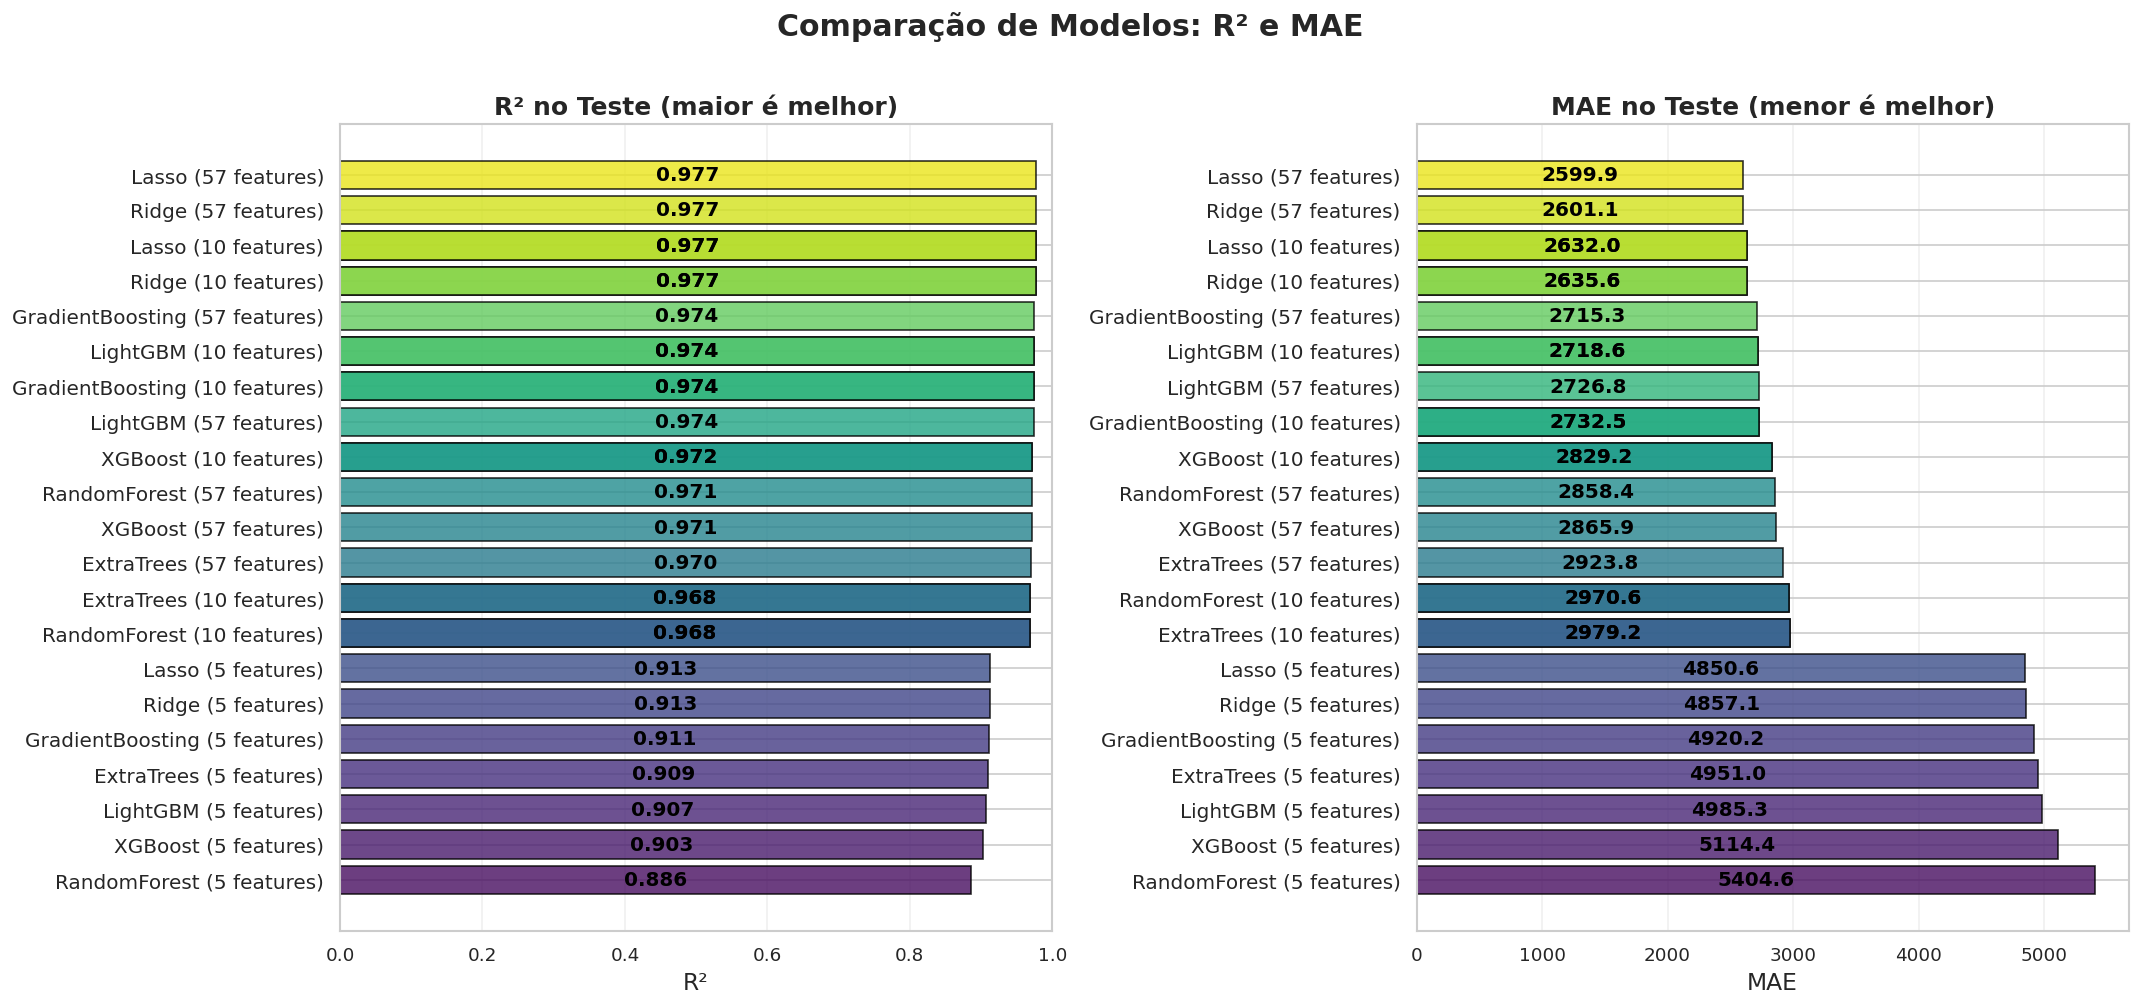

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usar o DataFrame de resultados já existente
resultados = resultados_df.copy()

# Criar um rótulo mais descritivo para incluir o número de features
resultados['Modelo_Features'] = resultados['Modelo'] + ' (' + resultados['Total de Features'].astype(str) + ' features)'

# Criar figura com 1 linha e 2 colunas para os 2 plots horizontais (R² e MAE)
fig, axes = plt.subplots(1, 2, figsize=(18, 9)) # Ajustar tamanho da figura
fig.suptitle('Comparação de Modelos: R² e MAE', fontsize=18, fontweight='bold')

# 1. R² Comparativo
ax = axes[0]
# Sort for R² plot (descending R²)
r_squared_sorted = resultados.sort_values(by=['R²'], ascending=True)
bars = ax.barh(r_squared_sorted['Modelo_Features'], r_squared_sorted['R²'],
              color=sns.color_palette('viridis', n_colors=len(r_squared_sorted)), alpha=0.8, edgecolor='black', linewidth=1)
ax.set_xlabel('R²', fontsize=14)
ax.set_title('R² no Teste (maior é melhor)', fontsize=15, fontweight='bold')
ax.set_xlim([0, 1]) # Limite para o eixo X (R²)
ax.grid(True, alpha=0.3, axis='x') # Grid no eixo X para barras horizontais
ax.tick_params(axis='y', labelsize=12) # Rótulos no eixo Y

# Adicionar valores DENTRO das barras
for bar, valor in zip(bars, r_squared_sorted['R²']):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height()/2.,
            f'{valor:.3f}', ha='center', va='center',
            color='black', fontweight='bold', fontsize=12)

# 2. MAE Comparativo
ax = axes[1]
# Sort for MAE plot (ascending MAE)
mae_sorted = resultados.sort_values(by=['MAE'], ascending=False)
bars = ax.barh(mae_sorted['Modelo_Features'], mae_sorted['MAE'],
              color=sns.color_palette('viridis', n_colors=len(mae_sorted)), alpha=0.8, edgecolor='black', linewidth=1)
ax.set_xlabel('MAE', fontsize=14)
ax.set_title('MAE no Teste (menor é melhor)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.tick_params(axis='y', labelsize=12)

# Adicionar valores DENTRO das barras
for bar, valor in zip(bars, mae_sorted['MAE']):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height()/2.,
            f'{valor:.1f}', ha='center', va='center',
            color='black', fontweight='bold', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.97]) # Ajustar layout para título superior
plt.show()

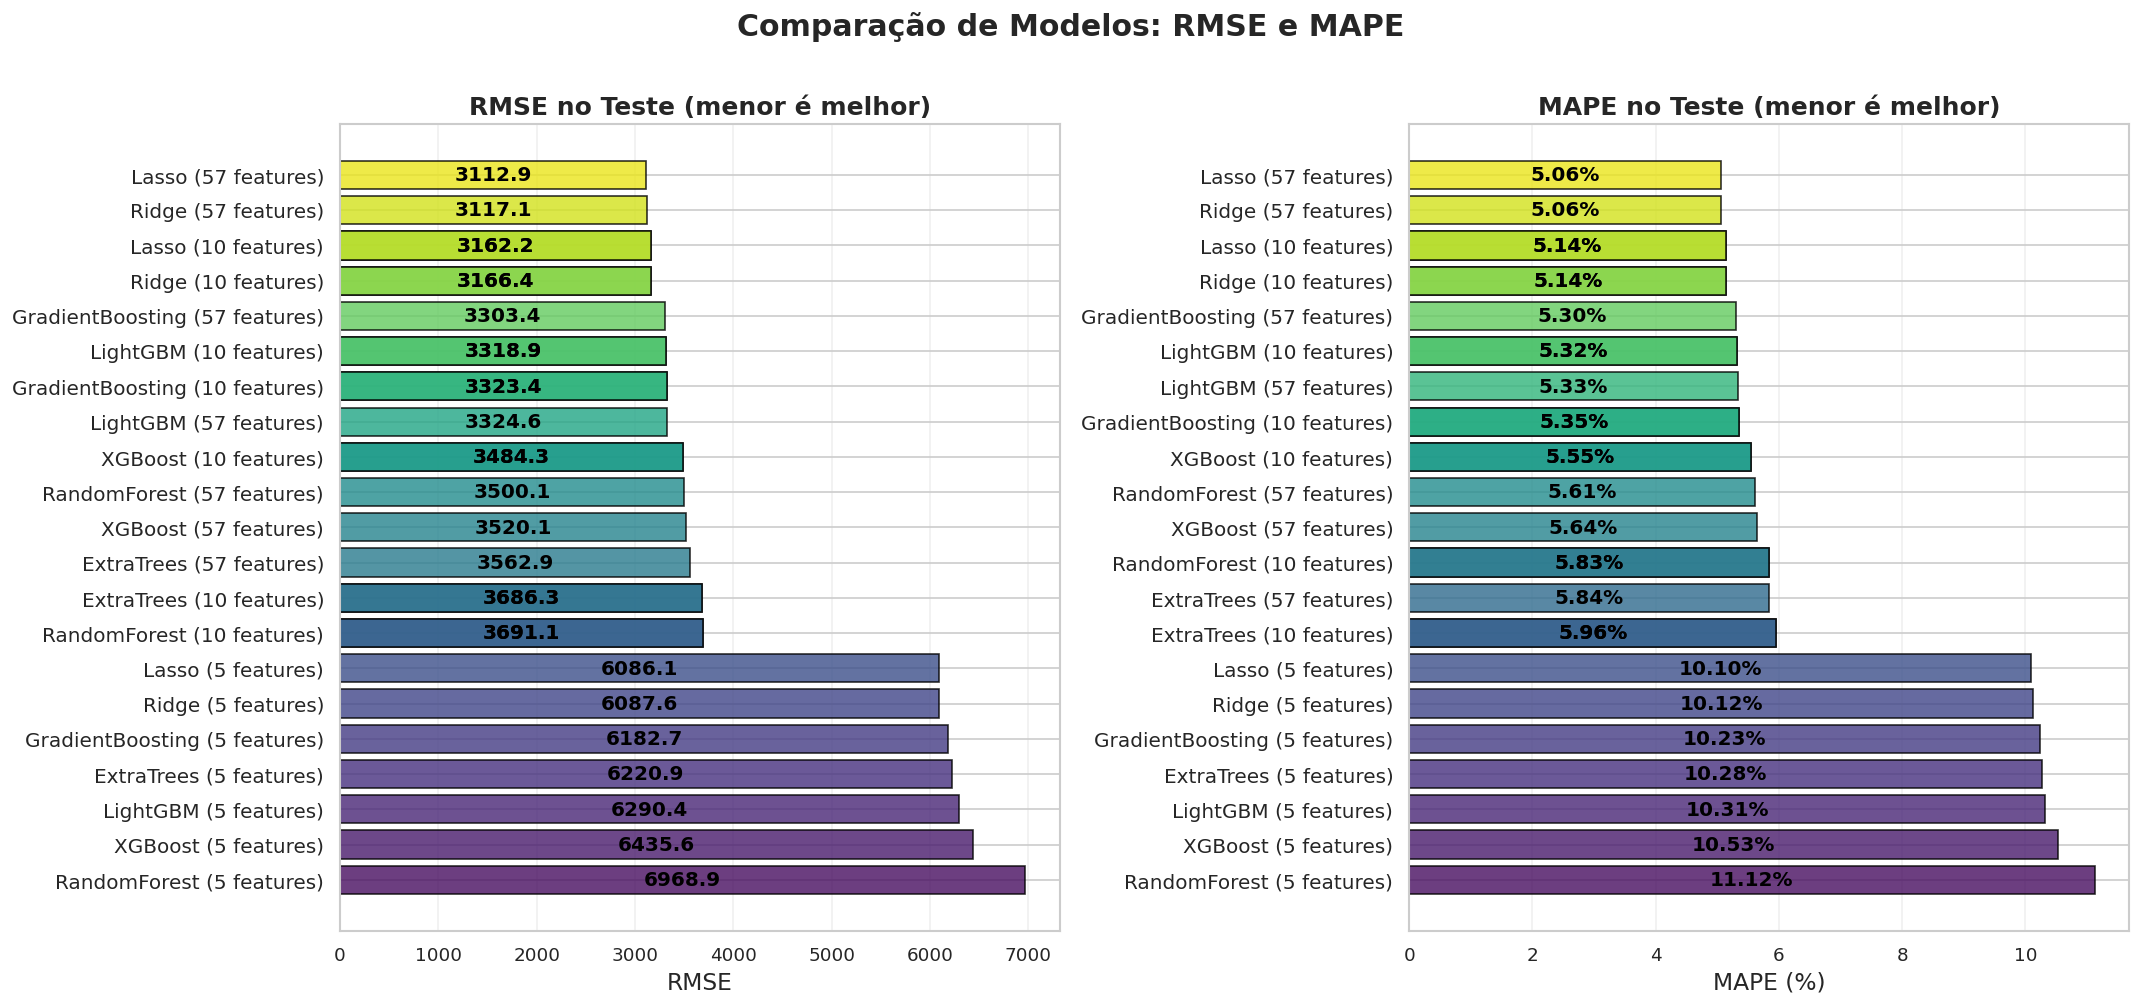

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usar o DataFrame de resultados já existente
resultados = resultados_df.copy()

# Criar um rótulo mais descritivo para incluir o número de features
resultados['Modelo_Features'] = resultados['Modelo'] + ' (' + resultados['Total de Features'].astype(str) + ' features)'

# Criar figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle('Comparação de Modelos: RMSE e MAPE', fontsize=18, fontweight='bold')

# =========================
# 1. RMSE Comparativo
# =========================
ax = axes[0]

# menor é melhor → inverter ordenação visual
rmse_sorted = resultados.sort_values(by=['RMSE'], ascending=False)

bars = ax.barh(rmse_sorted['Modelo_Features'], rmse_sorted['RMSE'],
              color=sns.color_palette('viridis', n_colors=len(rmse_sorted)),
              alpha=0.8, edgecolor='black', linewidth=1)

ax.set_xlabel('RMSE', fontsize=14)
ax.set_title('RMSE no Teste (menor é melhor)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.tick_params(axis='y', labelsize=12)

# valores dentro da barra
for bar, valor in zip(bars, rmse_sorted['RMSE']):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height()/2.,
            f'{valor:.1f}', ha='center', va='center',
            color='black', fontweight='bold', fontsize=12)

# =========================
# 2. MAPE Comparativo
# =========================
ax = axes[1]

# menor é melhor
mape_sorted = resultados.sort_values(by=['MAPE'], ascending=False)

bars = ax.barh(mape_sorted['Modelo_Features'], mape_sorted['MAPE'],
              color=sns.color_palette('viridis', n_colors=len(mape_sorted)),
              alpha=0.8, edgecolor='black', linewidth=1)

ax.set_xlabel('MAPE (%)', fontsize=14)
ax.set_title('MAPE no Teste (menor é melhor)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.tick_params(axis='y', labelsize=12)

# valores dentro da barra
for bar, valor in zip(bars, mape_sorted['MAPE']):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height()/2.,
            f'{valor:.2f}%', ha='center', va='center',
            color='black', fontweight='bold', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

### Foi escolhido o modelo que usa apenas 10 features, pois a diferença de performance nao justificava usar todas as 57 features.


## Pipeline
###Criar um Pipeline, onde o tratamento de encoder seja aplicado.

In [ ]:
df.columns

Index(['Marca', 'Modelo', 'Ano', 'Quilometragem', 'Cor', 'Cambio',
       'Combustivel', 'Portas', 'Valor_Venda', 'idade_carro'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Redefine X and y from the original DataFrame
X_full = df.drop(columns=['Valor_Venda'])
y_full = df['Valor_Venda']

# Identify categorical and numerical columns from the original df
categorical_cols = ['Marca', 'Modelo', 'Cor', 'Cambio', 'Combustivel']
numerical_cols = ['Ano', 'Quilometragem', 'Portas', 'idade_carro']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Keep other columns if any, though not expected here
)

# Create the full pipeline
pipeline_with_encoder = Pipeline([
    ('preprocessor', preprocessor),
    ('lgbm', LGBMRegressor(random_state=42, verbose=-1))
])

# Split the full dataset into training and testing sets
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

print("X_full:", X_full.shape)
print("Treino (80%):",X_train_full.shape)
print("Teste (20%):",X_test_full.shape)

X_full: (9686, 9)
Treino (80%): (7748, 9)
Teste (20%): (1938, 9)


In [ ]:
X_full.columns

Index(['Marca', 'Modelo', 'Ano', 'Quilometragem', 'Cor', 'Cambio',
       'Combustivel', 'Portas', 'idade_carro'],
      dtype='object')


### GridSearch

In [ ]:
# Define the parameter grid for GridSearchCV
param_grid_full = {
    'lgbm__n_estimators': [200, 300, 400],
    'lgbm__learning_rate': [0.05, 0.1, 0.2],
    'lgbm__num_leaves': [10, 20, 30],
    'lgbm__max_depth': [5, 10, -1]
}

# Initialize KFold for cross-validation
kf_full = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV
grid_full = GridSearchCV(
    pipeline_with_encoder,
    param_grid_full,
    cv=kf_full,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Treinando o modelo com o pipeline completo e buscando os melhores parametros")
grid_full.fit(X_train_full, y_train_full)

print("\nGridSearch com Encoder no Pipeline\n Melhores parâmetros:", grid_full.best_params_)
print("\nMelhor score CV:", grid_full.best_score_)

best_model_full_pipeline = grid_full.best_estimator_

test_score_full_pipeline = best_model_full_pipeline.score(X_test_full, y_test_full)
print("R2 no teste:", round(test_score_full_pipeline,4))
y_pred_test_full_pipeline = best_model_full_pipeline.predict(X_test_full)
print(f"MAE teste : {mean_absolute_error(y_test_full, y_pred_test_full_pipeline):.2f}")

Treinando o modelo com o pipeline completo e buscando os melhores parametros
Fitting 5 folds for each of 81 candidates, totalling 405 fits

GridSearch com Encoder no Pipeline
 Melhores parâmetros: {'lgbm__learning_rate': 0.05, 'lgbm__max_depth': 10, 'lgbm__n_estimators': 300, 'lgbm__num_leaves': 20}

Melhor score CV: 0.9755521574137989
R2 no teste: 0.9752
MAE teste : 2683.15


### Salvar o melhor modelo gerado com o gridsearch

In [ ]:
import joblib

# Salvar o modelo (pipeline completa) para uso futuro
model_filename = 'lgbm_best_full_model_pipeline.pkl'
joblib.dump(best_model_full_pipeline, model_filename)

print(f"Modelo salvo em '{model_filename}'")

Modelo salvo em 'lgbm_best_full_model_pipeline.pkl'


In [ ]:
X_train.columns

Index(['Quilometragem', 'Ano', 'Marca_Toyota', 'Marca_Jeep', 'Marca_Honda',
       'Marca_Fiat', 'Marca_Renault', 'Marca_Volkswagen', 'Marca_Nissan',
       'Marca_Ford'],
      dtype='object')